## 2. Data understanding/EDA

This section analyzes the COVID-19 dataset before preprocessing. The structure of the dataset is identified along with any potential data issues. Relationships between the variables that may affect the models are determined.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# COVID Test Result Classification

ADTA 4230 Final Project - Benjamin Wilcox, Matthew Flores

## 1. Introduction / Business Understanding

## 2. Data Understanding / EDA

In [ ]:
df.head()

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
0,0,0,0,0,0,No,female,0,negative
1,0,0,0,0,0,No,female,0,negative
2,1,0,0,0,0,No,female,0,negative
3,0,0,0,0,0,No,male,0,negative
4,0,0,0,0,0,No,female,0,negative


In [ ]:
# Additional libraries for the EDA plots
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028123 entries, 0 to 1028122
Data columns (total 9 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   Cough                1028123 non-null  int64
 1   Fever                1028123 non-null  int64
 2   Sore_Throat          1028123 non-null  int64
 3   Shortness_Of_Breath  1028123 non-null  int64
 4   Headache             1028123 non-null  int64
 5   Age_60_And_Above     978493 non-null   str  
 6   Sex                  1028123 non-null  str  
 7   Contact              1028123 non-null  int64
 8   Result               1028123 non-null  str  
dtypes: int64(6), str(3)
memory usage: 70.6 MB


In [ ]:
# Summary statistics for all columns
df.describe(include='all')

,Cough,Fever,Sore_Throat,Shortness_Of_Breath,Headache,Age_60_And_Above,Sex,Contact,Result
count,1.028123e+06,1.028123e+06,1.028123e+06,1.028123e+06,1.028123e+06,978493,1028123,1.028123e+06,1028123
unique,NaN,NaN,NaN,NaN,NaN,2,2,NaN,2
top,NaN,NaN,NaN,NaN,NaN,No,female,NaN,negative
freq,NaN,NaN,NaN,NaN,NaN,848099,528254,NaN,922995
mean,2.682753e-02,2.719422e-02,8.993087e-03,2.721464e-03,1.891311e-02,NaN,NaN,6.308097e-02,NaN
std,1.615792e-01,1.626491e-01,9.440456e-02,5.209665e-02,1.362183e-01,NaN,NaN,2.431087e-01,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN


Result
negative    922995
positive    105128
Name: count, dtype: int64
Result
negative    0.897748
positive    0.102252
Name: count, dtype: float64


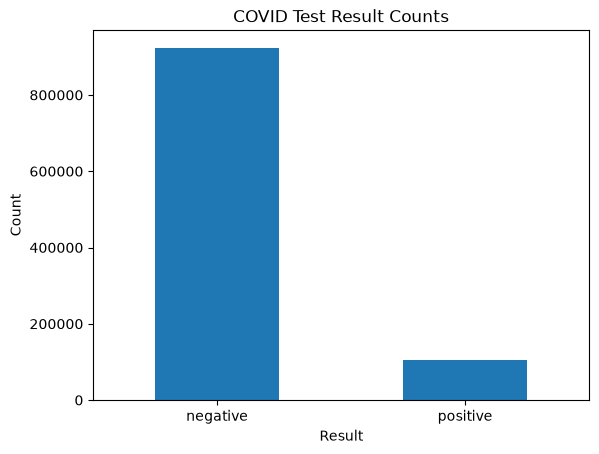

In [ ]:
# Distribution of the target variable. Note that only about 10% of tests are positive,
# so raw accuracy will be a misleading evaluation metric later
result_counts = df['Result'].value_counts()
print(result_counts)
print(result_counts / len(df))

result_counts.plot(kind='bar')
plt.title('COVID Test Result Counts')
plt.xlabel('Result')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

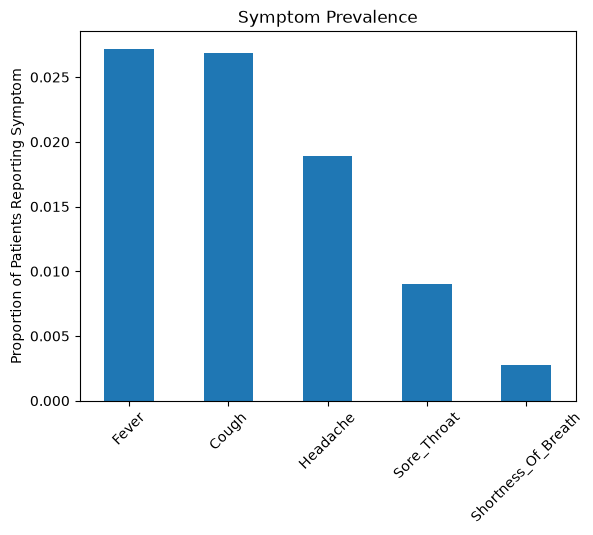

In [ ]:
# Prevalence of each symptom across all patients
symptom_cols = ['Cough', 'Fever', 'Sore_Throat', 'Shortness_Of_Breath', 'Headache']
symptom_rates = df[symptom_cols].mean().sort_values(ascending=False)

symptom_rates.plot(kind='bar')
plt.title('Symptom Prevalence')
plt.ylabel('Proportion of Patients Reporting Symptom')
plt.xticks(rotation=45)
plt.show()

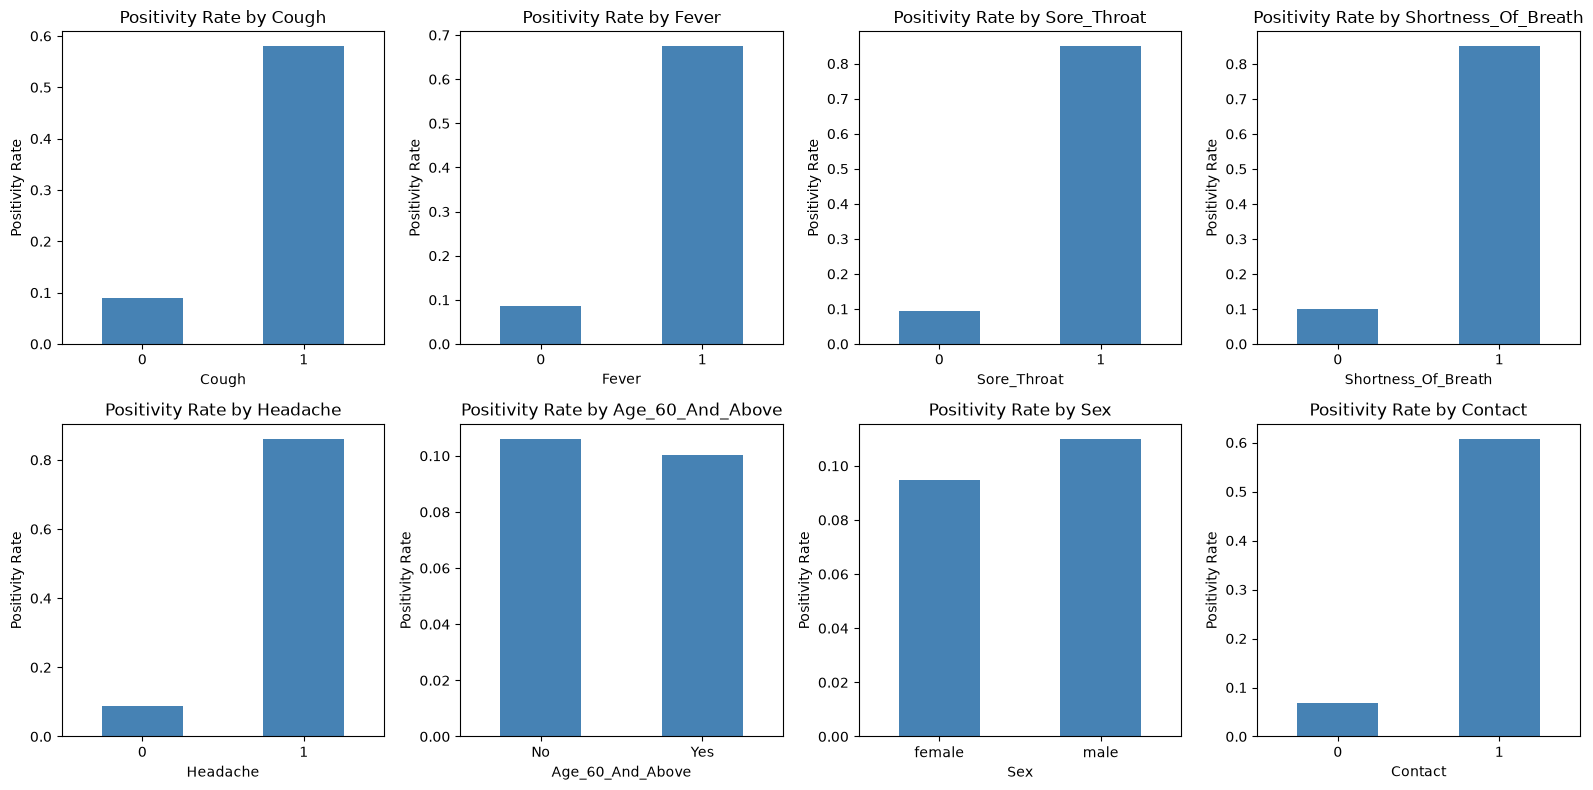

In [ ]:
# Below is the positivity rate by each predictor; for every predictor, 
# compare the share of positive results between its two groups.
# This metric shows association with the target a lot better than than the raw count does.
predictor_cols = symptom_cols + ['Age_60_And_Above', 'Sex', 'Contact']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, predictor_cols):
    rates = df.groupby(col)['Result'].apply(lambda s: (s == 'positive').mean())
    rates.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Positivity Rate by {col}')
    ax.set_ylabel('Positivity Rate')
    ax.tick_params(axis='x', rotation=0)
# Note that the code above that was used for plot generation was partially generated by ChatGPT to aid in making good-looking plt figures.

plt.tight_layout()
plt.show()

In [ ]:
# Missing values per column
# Only Age_60_And_Above has gaps (this is addressed later in Section 3)
print(df.isna().sum())

Cough                      0
Fever                      0
Sore_Throat                0
Shortness_Of_Breath        0
Headache                   0
Age_60_And_Above       49630
Sex                        0
Contact                    0
Result                     0
dtype: int64


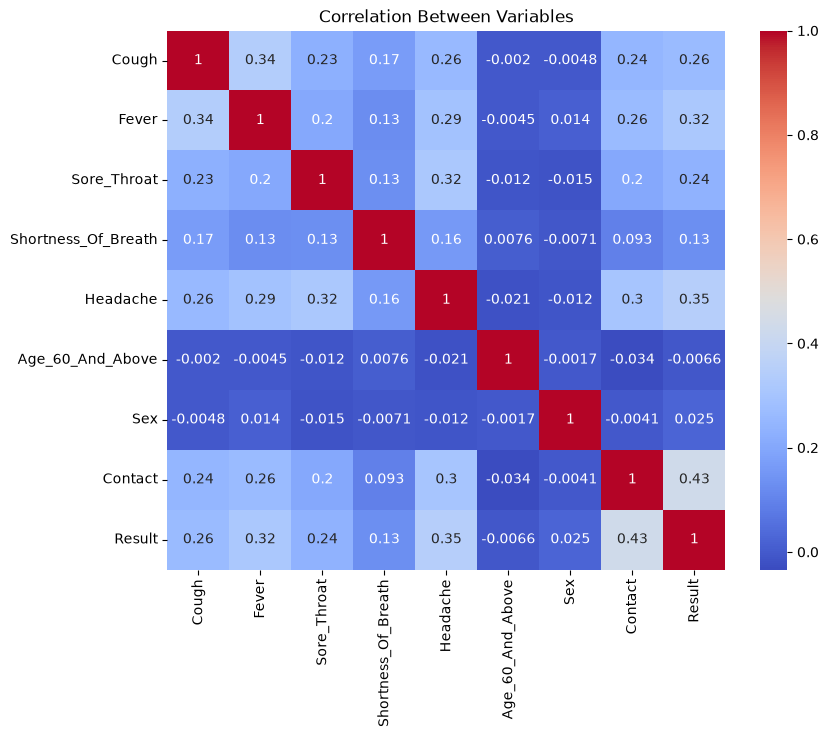

In [32]:
# Here is a correlation heatmap of the predictors and target
# I use temporary encoding for the plot only
encoded = df.copy()
encoded['Age_60_And_Above'] = encoded['Age_60_And_Above'].map({'Yes': 1, 'No': 0})
encoded['Sex'] = encoded['Sex'].map({'male': 1, 'female': 0})
encoded['Result'] = encoded['Result'].map({'positive': 1, 'negative': 0})

plt.figure(figsize=(9, 7))
sns.heatmap(encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Variables')
plt.show()

## 3. Data Preparation

### Missing Values

In [ ]:
# Count missing values in every column
missing = df.isnull().sum()

In [33]:
There is a strong association between exposure and infection. Among individuals with **no contact**, **93%** tested **negative**, while **7%** tested **positive**. Individuals with **known contact**, **61%** tested positive and **39%** tested **negative**. This suggests that contact with a person confirmed to have COVID-19 is a strong predictor of a positive test result.

np.int64(49630)

### Correlation Analysis

A correlation matrix is used to examine the relationships among the predictor variables.

In [ ]:
# Create a temporary copy
temp = df.copy()

In [ ]:
# Convert the target variable to numeric
temp["Result_Num"] = temp["Result"].map({
    "negative": 0,
    "positive": 1
})

In [ ]:
# Select variables for correlation analysis
corr_cols = [
    "Cough",
    "Fever",
    "Sore_Throat",
    "Shortness_Of_Breath",
    "Headache",
    "Age_60_And_Above",
    "Contact",
    "Result_Num"
]

In [ ]:
# Convert Age_60_And_Above from Yes/No to 1/0
temp["Age_60_And_Above"] = temp["Age_60_And_Above"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
# Drop rows with missing values in the selected columns
corr_data = temp[corr_cols].dropna()

In [ ]:
# Compute correlation matrix
corr_matrix = corr_data.corr()

In [34]:
# Plot heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Predictor Variables and COVID-19 Test Result")
plt.savefig("Figure6.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation matrix shows that most predictor variables have weak positive correlations with one another, suggesting that each variable uniquely correlates to a positive test result. The strongest relationship with the target variable is **Contact** (r = 0.44). This indicates that contact with an infected individual is the strongest predictor of a positive COVID-19 test result. From the symptoms, **Headache** (r = 0.35) and **Fever** (r = 0.32) have the strongest correlations with a positive test result. Since no pair has a strong correlation, multicollinearity is unlikely to be a factor for the models developed.

### Age (60+) vs. Test Result

This section looks at the relationship between age and COVID-19 test results. This helps determine if age is associated with an increased chance of testing positive for COVID-19.

In [ ]:
age_result = pd.crosstab(
    df["Age_60_And_Above"],
    df["Result"],
    normalize="index"
) * 100

age_result

In [35]:
df["Age_60_And_Above"].isna().sum()

np.int64(0)

## 4. Modeling

### 4.1 Logistic Regression

### 4.2 K-Nearest Neighbors

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

myData = df.copy()
myData['Age_60_And_Above'] = myData['Age_60_And_Above'].map({'Yes': 1, 'No': 0})
myData['Sex'] = myData['Sex'].map({'male': 1, 'female': 0})
myData['Result'] = myData['Result'].map({'positive': 1, 'negative': 0})

# Use a sample of the data instead of the full thing becase 
# KNN scales quickly with more data and there are 1M rows
myData, _ = train_test_split(myData,
                             train_size = 50000,
                             stratify = myData.Result,
                             random_state = 321)

# split into train (60%) and test (40%), stratified since only ~10% are positive cases
X_train, X_test, y_train, y_test = train_test_split(myData.drop('Result', axis = 1),
                                                    myData.Result,
                                                    test_size = 0.40,
                                                    stratify = myData.Result,
                                                    random_state = 321)

# standardize the predictors
scaler = StandardScaler()
dataScaler = scaler.fit(myData.drop('Result', axis = 1))

X_train_std = dataScaler.transform(X_train)
X_test_std = dataScaler.transform(X_test)

In [44]:
# 10-fold cross validation over k = 1 to 20, using accuracy
KNN_model = KNeighborsClassifier()
paramGrid = {'n_neighbors': range(1, 20 + 1)}

search = GridSearchCV(KNN_model,
                      paramGrid,
                      cv = 10,
                      scoring = 'accuracy')

KNN_fit = search.fit(X_train_std, y_train)

pd.DataFrame(KNN_fit.cv_results_).sort_values('rank_test_score')[['param_n_neighbors', 'mean_test_score', 'rank_test_score']]

,param_n_neighbors,mean_test_score,rank_test_score
11,12,0.919267,1
19,20,0.919000,2
17,18,0.918933,3
8,9,0.918800,4
10,11,0.918767,5
18,19,0.918667,6
16,17,0.918633,7
14,15,0.918567,8
15,16,0.918500,9
12,13,0.918400,10


In [ ]:
# The optimal value of k
KNN_fit.best_estimator_

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 5. Evaluation

## 6. Deployment

## 7. Conclusion